In [11]:
import jax
import flax
import optax
from jax import lax, random, value_and_grad,numpy as jnp
from jax import random, grad, vmap, hessian, jacfwd, jit
from jax import config
from flax import linen as nn
import jax_dataloader as jd

import time
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import colors

import os
from tqdm.auto import tqdm

#os.environ['CUDA_VISIBLE_DEVICES'] = '1'
config.update("jax_enable_x64", True)
os.environ['XLA_PYTHON_CLIENT_ALLOCATOR'] = 'cuda_async'
os.environ['XLA_PYTHON_CLIENT_PREALLOCATE'] = 'true' # default is true, 90% of GPU VRAM preallocated

In [12]:
DATA_DIR = Path.cwd().parent.parent / "data" / "poisson-gauss" / "snapshots"


Dataset summary:
<xarray.Dataset> Size: 3GB
Dimensions:   (sample: 20000, x: 128, y: 128)
Dimensions without coordinates: sample, x, y
Data variables:
    solution  (sample, x, y) float32 1GB ...
    source    (sample, x, y) float32 1GB ...

Extracted Source Shape: (128, 128)
Extracted Solution Shape: (128, 128)


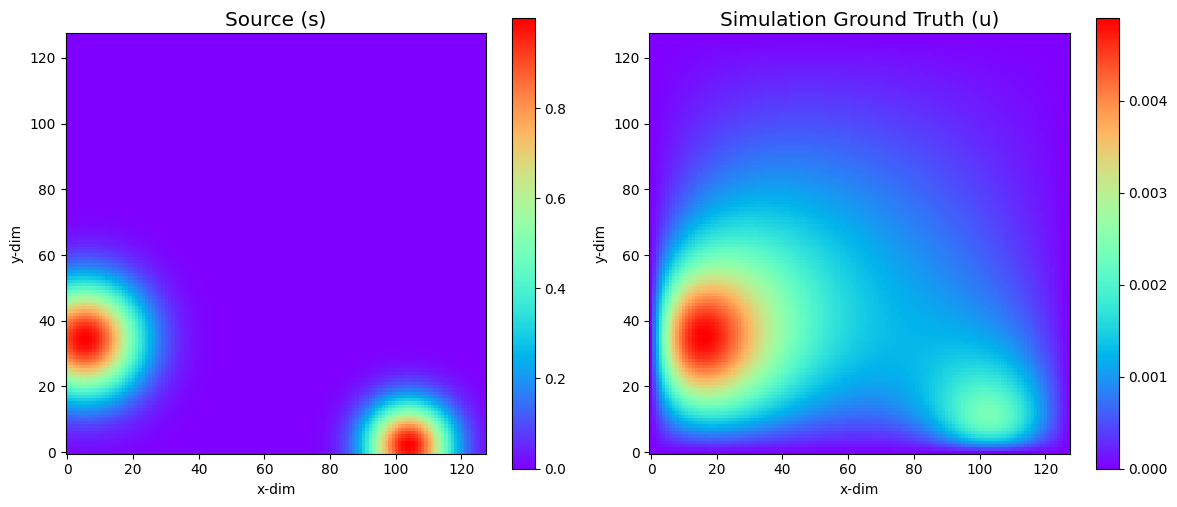

In [13]:
import xarray as xr

DATA_DIR = Path.cwd().parent.parent / "data" / "poisson-gauss" / "snapshots"
FILE_PATH = DATA_DIR / "Poisson-Gauss.nc" 

ds = xr.open_dataset(FILE_PATH)
print(f"Dataset summary:\n{ds}\n")

sample_idx = 0
source_sample = ds['source'][sample_idx].values
solution_sample = ds['solution'][sample_idx].values

print(f"Extracted Source Shape: {source_sample.shape}")
print(f"Extracted Solution Shape: {solution_sample.shape}")

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

im1 = axes[0].imshow(source_sample.T, origin='lower', cmap='rainbow')
fig.colorbar(im1, ax=axes[0])
axes[0].set_title('Source (s)', fontsize='x-large')
axes[0].set_xlabel('x-dim')
axes[0].set_ylabel('y-dim')

im2 = axes[1].imshow(solution_sample.T, origin='lower', cmap='rainbow')
fig.colorbar(im2, ax=axes[1])
axes[1].set_title('Simulation Ground Truth (u)', fontsize='x-large')
axes[1].set_xlabel('x-dim')
axes[1].set_ylabel('y-dim')
plt.tight_layout()
plt.show()

ds.close()

In [14]:
nx, ny = source_sample.shape # 128, 128

# normalize
x_coords = np.linspace(0.0, 1.0, nx, dtype=np.float64)
y_coords = np.linspace(0.0, 1.0, ny, dtype=np.float64)

X, Y = np.meshgrid(x_coords, y_coords, indexing='ij')

x = jnp.array(X.reshape(-1, 1))
y = jnp.array(Y.reshape(-1, 1))

s = jnp.array(source_sample.reshape(-1, 1), dtype=jnp.float64)
u_sim = jnp.array(solution_sample.reshape(-1, 1), dtype=jnp.float64)

# Dirichlet Boundary Condition
x_l, x_u = 0.0, 1.0
y_l, y_u = 0.0, 1.0

bc_left = (x == x_l).flatten() # Array([ True,  True,  True, ..., False, False, False], dtype=bool)
bc_right = (x == x_u).flatten()
bc_bottom = (y == y_l).flatten()
bc_top = (y == y_u).flatten()

bc_all = bc_left | bc_right | bc_bottom | bc_top # an array of True if on boundary, False if not on boundary.

# Extract only boundary coordinates
x_bc = x[bc_all]
y_bc = y[bc_all]

u_bc = jnp.zeros_like(x_bc) # Dirichlet u=0


In [15]:
class FeatureExtractor(nn.Module):
    hidden_layers: list
    out_features: int # m (no. of columns)
    
    @nn.compact
    def __call__(self, x_in, y_in):
        x_val = jnp.squeeze(x_in)
        y_val = jnp.squeeze(y_in)
        h = jnp.stack([x_val, y_val])
        
        for size in self.hidden_layers:
            h = nn.Dense(size, kernel_init=nn.initializers.he_normal())(h)
            h = nn.tanh(h) 
            
        features = nn.Dense(self.out_features, kernel_init=nn.initializers.he_normal())(h)
        return features

model = FeatureExtractor(hidden_layers=[50, 50, 50], out_features=150) # future: can use optuna to find best hyperparams

# Dummy initialization to get the shapes right
key = jax.random.PRNGKey(0)
dummy_x, dummy_y = jnp.array([0.0]), jnp.array([0.0])
params = model.init(key, dummy_x, dummy_y)

def get_f(params, x_val, y_val):
    return model.apply(params, x_val, y_val)

def get_f_dir(params, x_val, y_val):
    f = get_f(params, x_val, y_val)
    
    f_x = jacfwd(get_f, argnums=1)(params, x_val, y_val)
    f_y = jacfwd(get_f, argnums=2)(params, x_val, y_val)
    
    f_xx = jacfwd(jacfwd(get_f, argnums=1), argnums=1)(params, x_val, y_val)
    f_yy = jacfwd(jacfwd(get_f, argnums=2), argnums=2)(params, x_val, y_val)

    f_x = jnp.squeeze(f_x, axis=-1)
    f_y = jnp.squeeze(f_y, axis=-1)
    
    f_xx = jnp.squeeze(f_xx, axis=(-1, -2))
    f_yy = jnp.squeeze(f_yy, axis=(-1, -2))

    return f, f_x, f_y, f_xx, f_yy

# VMAP over the batch dimension (axis 0 for x and y, None for params)
f_vmap = vmap(get_f, in_axes=(None, 0, 0))
f_dir_vmap = vmap(get_f_dir, in_axes=(None, 0, 0))

In [16]:
optimizer = optax.adamw(learning_rate=1e-4, weight_decay=1e-4)

# freeze final linear layer weights
def compute_loss(params, w_current, x_batch, y_batch, s_batch, x_bc, y_bc, u_bc):
    _, _, _, f_xx, f_yy = f_dir_vmap(params, x_batch, y_batch)
    
    u_xx = jnp.dot(f_xx, w_current)
    u_yy = jnp.dot(f_yy, w_current)
    laplacian_u = u_xx + u_yy
    
    pde_residual = laplacian_u + s_batch
    loss_pde = jnp.mean(pde_residual ** 2)
    
    # Boundary Condition Loss (Dirichlet u = 0) 
    f_bc_vals = f_vmap(params, x_bc, y_bc)
    u_bc_pred = jnp.dot(f_bc_vals, w_current)
    loss_bc = jnp.mean((u_bc_pred - u_bc) ** 2) * 1000.0
    
    total_loss = loss_pde + loss_bc # Might need to add weighted values here later
    return total_loss

loss_grad_fn = jax.jit(value_and_grad(compute_loss, argnums=0))

@jax.jit
def update_hidden(params, opt_state, w_current, x_batch, y_batch, s_batch, x_bc, y_bc, u_bc):
    """
    Takes a gradient descent step on the hidden weights (params) while freezing w.
    """
    loss, grads = loss_grad_fn(params, w_current, x_batch, y_batch, s_batch, x_bc, y_bc, u_bc)
    
    updates, opt_state = optimizer.update(grads, opt_state, params=params)
    new_params = optax.apply_updates(params, updates)
    
    return new_params, opt_state, loss

In [17]:
@jit
def kaczmarz_step(A_B, b_B, w_current, alpha, batch_weight_decay): 
    block_size = A_B.shape[0]
    r = A_B @ w_current - b_B
    gram = A_B @ A_B.T + 1e-6 * jnp.eye(block_size)
    z = jnp.linalg.solve(gram, r)    
    w_new = w_current - alpha * (A_B.T @ z)
    # w_new = (1.0 - batch_weight_decay) * w_current - alpha * (A_B.T @ z) <<< If we require weight decay for linear weights
    return w_new

# try to find a way that does not even need to build the A matrix
@jit
def build_and_update_kaczmarz(params, w_current, x_batch, y_batch, s_batch, x_bc, y_bc, u_bc, alpha, batch_weight_decay):
    """
    Builds the A and b matrices for the current batch and applies the Kaczmarz step.
    """
    _, _, _, f_xx, f_yy = f_dir_vmap(params, x_batch, y_batch)
    A_pde = f_xx + f_yy
    b_pde = -s_batch

    A_bc = f_vmap(params, x_bc, y_bc) * jnp.sqrt(1000.0)
    b_bc = u_bc * jnp.sqrt(1000.0)
    
    A_block = jnp.vstack([A_pde, A_bc])
    b_block = jnp.vstack([b_pde, b_bc])
    
    w_updated = kaczmarz_step(A_block, b_block, w_current, alpha, batch_weight_decay)
    return w_updated

In [18]:
epochs = 100
batch_size = 1024
alpha = 1e-4      # Kaczmarz relaxation parameter
total_points = x.shape[0]

epoch_weight_decay = 1e-4  # for linear weights
N = int(np.ceil(total_points / batch_size)) # Number of batches per epoch
batch_weight_decay = 1.0 - (1.0 - epoch_weight_decay) ** (1.0 / N)

# Initialize the final linear weights (w) to zeros
# Size M=150 to match out_features of the FeatureExtractor
M = 150
w = jnp.zeros((M, 1))

opt_state = optimizer.init(params)

rng = jax.random.PRNGKey(42)
        
for epoch in tqdm(range(epochs), desc=f"Training {epochs} Epochs"):
    rng, shuffle_key = jax.random.split(rng)
    
    indices = jax.random.permutation(shuffle_key, total_points) # shuffled indices for the PDE points
    
    epoch_loss = 0.0
    num_batches = 0
    
    # Process the domain in chunks (mini-batches)
    for i in range(0, total_points, batch_size):
        batch_idx = indices[i : i + batch_size] # sampling without replacement for 1 epoch
        
        x_batch = x[batch_idx]
        y_batch = y[batch_idx]
        s_batch = s[batch_idx]
        
        # NOTE: We are passing the full boundary condition arrays (x_bc, y_bc) into 
        # every step here. If it is too much, we should use cyclic sampling of bc with mini-batching.
        
        # Update Linear Weights (w)
        w = build_and_update_kaczmarz(params, w, x_batch, y_batch, s_batch, x_bc, y_bc, u_bc, alpha, batch_weight_decay)
        
        # Update Hidden Weights (params)
        params, opt_state, loss = update_hidden(params, opt_state, w, x_batch, y_batch, s_batch, x_bc, y_bc, u_bc)
        
        epoch_loss += loss
        num_batches += 1
        
    avg_loss = epoch_loss / num_batches
    
    if epoch % 10 == 0 or epoch == epochs - 1:
        # Calculate full-grid MSE with frozen w and params
        f_all = f_vmap(params, x, y)
        u_pred = f_all @ w
        mse = jnp.mean((u_pred - u_sim)**2)
        
        print(f"Epoch {epoch:03d} | PDE/BC Loss: {avg_loss:.4e} | Full Grid MSE vs Ground Truth: {mse:.4e}")

print("Training Complete!")

Training 100 Epochs:   0%|          | 0/100 [00:00<?, ?it/s]

Epoch 000 | PDE/BC Loss: 3.0351e-02 | Full Grid MSE vs Ground Truth: 1.1370e-06
Epoch 010 | PDE/BC Loss: 1.2954e-02 | Full Grid MSE vs Ground Truth: 3.0173e-07
Epoch 020 | PDE/BC Loss: 7.4086e-03 | Full Grid MSE vs Ground Truth: 1.3616e-07
Epoch 030 | PDE/BC Loss: 5.9176e-03 | Full Grid MSE vs Ground Truth: 1.7221e-07
Epoch 040 | PDE/BC Loss: 5.0643e-03 | Full Grid MSE vs Ground Truth: 2.1814e-07
Epoch 050 | PDE/BC Loss: 4.5721e-03 | Full Grid MSE vs Ground Truth: 8.7465e-08
Epoch 060 | PDE/BC Loss: 4.2873e-03 | Full Grid MSE vs Ground Truth: 5.1757e-08
Epoch 070 | PDE/BC Loss: 4.1479e-03 | Full Grid MSE vs Ground Truth: 2.0771e-07
Epoch 080 | PDE/BC Loss: 4.0031e-03 | Full Grid MSE vs Ground Truth: 7.2870e-08
Epoch 090 | PDE/BC Loss: 3.9450e-03 | Full Grid MSE vs Ground Truth: 9.3306e-08
Epoch 099 | PDE/BC Loss: 3.8605e-03 | Full Grid MSE vs Ground Truth: 4.3255e-08
Training Complete!


In [19]:
# But we have a params[-1] thing i think we need to also train for the regularization

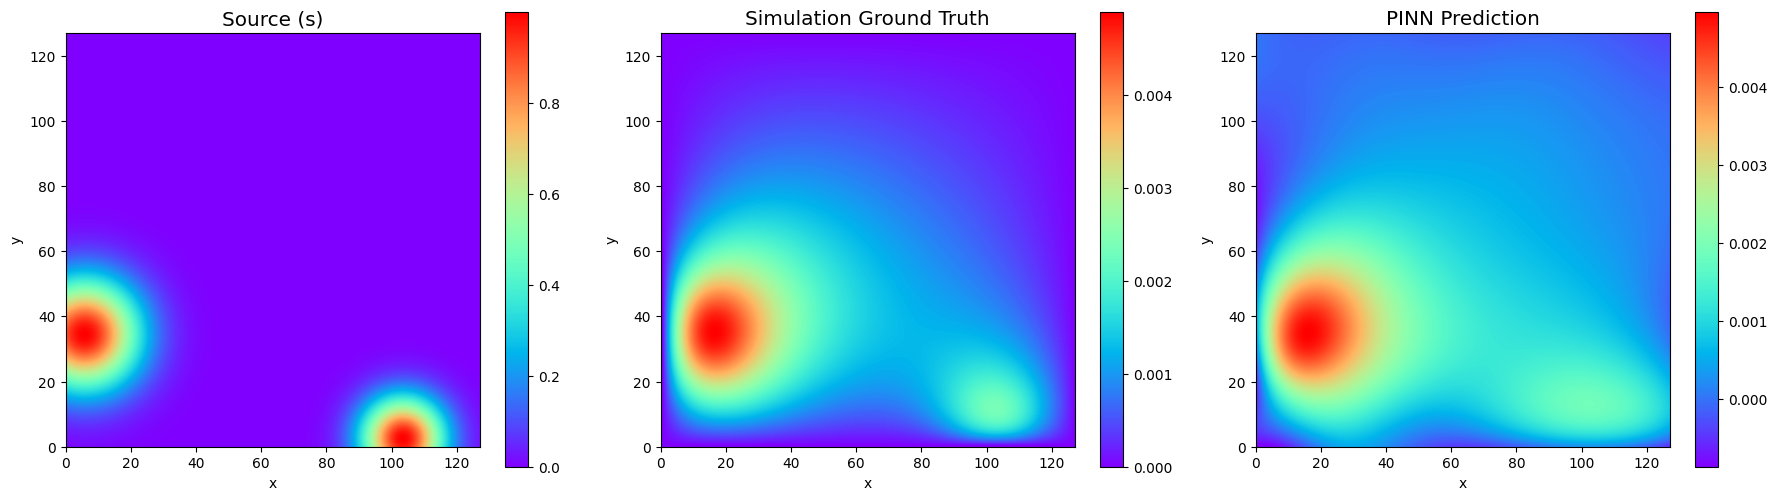

In [20]:
f_all = f_vmap(params, x, y)
u_pred = f_all @ w
ext = [0, nx - 1, 0, ny - 1]

fig = plt.figure(figsize=(18, 5))

ax1 = fig.add_subplot(1, 3, 1)
s_plot = s.reshape(nx, ny).T  
mesh1 = ax1.imshow(s_plot, interpolation='bilinear', origin='lower', cmap='rainbow', extent=ext, aspect=1.)
fig.colorbar(mesh1, ax=ax1)
ax1.set_xlabel('x')
ax1.set_ylabel('y')
ax1.set_title('Source (s)', fontsize='x-large')

ax2 = fig.add_subplot(1, 3, 2)
u_sim_plot = u_sim.reshape(nx, ny).T 
mesh2 = ax2.imshow(u_sim_plot, interpolation='bilinear', origin='lower', cmap='rainbow', extent=ext, aspect=1.)
fig.colorbar(mesh2, ax=ax2)
ax2.set_xlabel('x')
ax2.set_ylabel('y')
ax2.set_title('Simulation Ground Truth', fontsize='x-large')

ax3 = fig.add_subplot(1, 3, 3)
u_pred_plot = u_pred.reshape(nx, ny).T
mesh3 = ax3.imshow(u_pred_plot, interpolation='bilinear', origin='lower', cmap='rainbow', extent=ext, aspect=1.)
fig.colorbar(mesh3, ax=ax3)
ax3.set_xlabel('x')
ax3.set_ylabel('y')
ax3.set_title('PINN Prediction', fontsize='x-large')

plt.tight_layout()
plt.show()